### Model analysis  

Під час EDA було одразу вказано, що ми маємо незбалансований таргет.  
Показників мінорного класу набагато менше.  
Співвідношення 13.4. Цей параметр було надано моделям lgb та xgb, щоб вони це врахували.  
Задля експерименту і порівняння була створена ще одна модель xgb з використанням методу балансування SMOTE.
Оскільки дисбаланс це одна з головних проблем цього датасету подивимось, чи зможе SMOTE з цим допомогти.

Завантажимо необхідні бібліотеки та підготуємо дані.  
Для даних беремо окремий датасет val_df. Ці дані складають 30% тренувального датасету.  
Ці 30% моделі не бачили.  
Отже, оцінка має бути чистою.

In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, roc_auc_score, log_loss, confusion_matrix, precision_recall_curve, f1_score
import xgboost as xgb
import lightgbm as lgb
import joblib

In [113]:
from sklearn.metrics import auc as calculate_auc

In [53]:
df_val = pd.read_csv('mid_project/val_df.csv')

In [54]:
df_val.head()

,age,number_dependent_family_members,monthly_income,number_of_credit_lines,real_estate_loans,ratio_debt_payment_to_income,credit_line_utilization,total_late_payments,target
0,49,0,8.594339,7,1,0.658098,0.176436,0,0
1,57,3,8.860925,11,3,0.294673,0.843004,0,0
2,53,3,7.978311,0,0,0.251286,0.016933,0,0
3,59,0,10.025218,7,1,0.074195,0.108344,0,0
4,46,0,8.962904,3,0,0.032147,0.000000,0,0


In [55]:
df_val.shape

(21649, 9)

In [57]:
X_val = df_val.drop('target', axis=1)
y_val = df_val['target']
X_val.shape, y_val.shape

((21649, 8), (21649,))

In [58]:
xgb_model = joblib.load('mid_project/xgb_kfold.joblib')
lgb_model = joblib.load('mid_project/lgb_kfold.joblib')
smote_xgb_model = joblib.load('mid_project/smote_xgb.joblib')

Моделі завантажено, спробуємо отримати передбачення на тренувальних даних.

In [59]:
y_proba_xgb_val = xgb_model.predict_proba(X_val)[:, 1]

In [60]:
y_proba_lgb_val = lgb_model.predict_proba(X_val)[:, 1]

In [61]:
y_proba_smote = smote_xgb_model.predict_proba(X_val)[:, 1]

In [62]:
y_proba_ens_val = (y_proba_xgb_val + y_proba_lgb_val) / 2

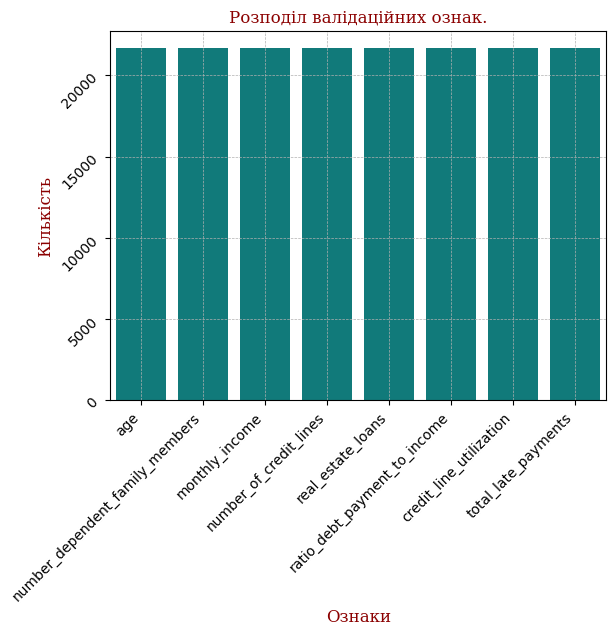

In [63]:
val_data = X_val.count()

sns.barplot(x=val_data.index, y=val_data.values, color='DarkCyan')

myfont = {'family':'serif','color':'darkred','size':12}

plt.title('Розподіл валідаційних ознак.', fontdict=myfont)
plt.yticks(rotation=45, ha="right")
plt.xticks(rotation=45, ha="right")
plt.xlabel('Ознаки', fontdict=myfont)
plt.ylabel('Кількість', fontdict=myfont)
plt.grid(linestyle = '--', linewidth = 0.5)
plt.show()

Для наших даних маємо рівномірний розподіл ознак.  
Перевіримо таргет.

In [64]:
val_target = y_val.value_counts()
val_target

target
0    20134
1     1515
Name: count, dtype: int64

In [65]:
train_imbalance = val_target[0] / val_target[1]
print(f'Дисбаланс тренувального таргету: {train_imbalance:.1f}')

Дисбаланс тренувального таргету: 13.3


На етапі підготовки нашого датасету цей дисбаланс був обрахований і вказаний у параметрах навчання моделей.  
Отже, моделі вже навчені з урахуванням саме цього дисбалансу.  
Зараз було підтверджено, він зберігається і досі для наших подальших кроків з оцінки точності.

Для моделі Smote цей параметр було видалено відповідно.

### Перевіримо наші метрики.  

In [100]:
auc = roc_auc_score(y_val, y_proba_xgb_val)
loss = log_loss(y_val, y_proba_xgb_val)

print(f'XGB Model'
      f'\nROC AUC: {auc:.4f}'
      f'\nLog-Loss: {loss:.4f}')

XGB Model
ROC AUC: 0.8457
Log-Loss: 0.1922


In [102]:
auc = roc_auc_score(y_val, y_proba_lgb_val)
loss = log_loss(y_val, y_proba_lgb_val)

print(f'LGB Model'
      f'\nROC AUC: {auc:.4f}'
      f'\nLog-Loss: {loss:.4f}')

LGB Model
ROC AUC: 0.8433
Log-Loss: 0.1935


In [103]:
auc = roc_auc_score(y_val, y_proba_ens_val)
loss = log_loss(y_val, y_proba_ens_val)

print(f'Ensemble'
      f'\nROC AUC: {auc:.4f}'
      f'\nLog-Loss: {loss:.4f}')

Ensemble
ROC AUC: 0.8450
Log-Loss: 0.1926


Маємо дуже гарні показники. Log Loss ближчий до 0, отже моделі призначають високі імовірності правильним відповідям.  
Roc Auc каже про те, що моделі не перенавчені, але вони можуть просто добре вгадувати тих кого більше.

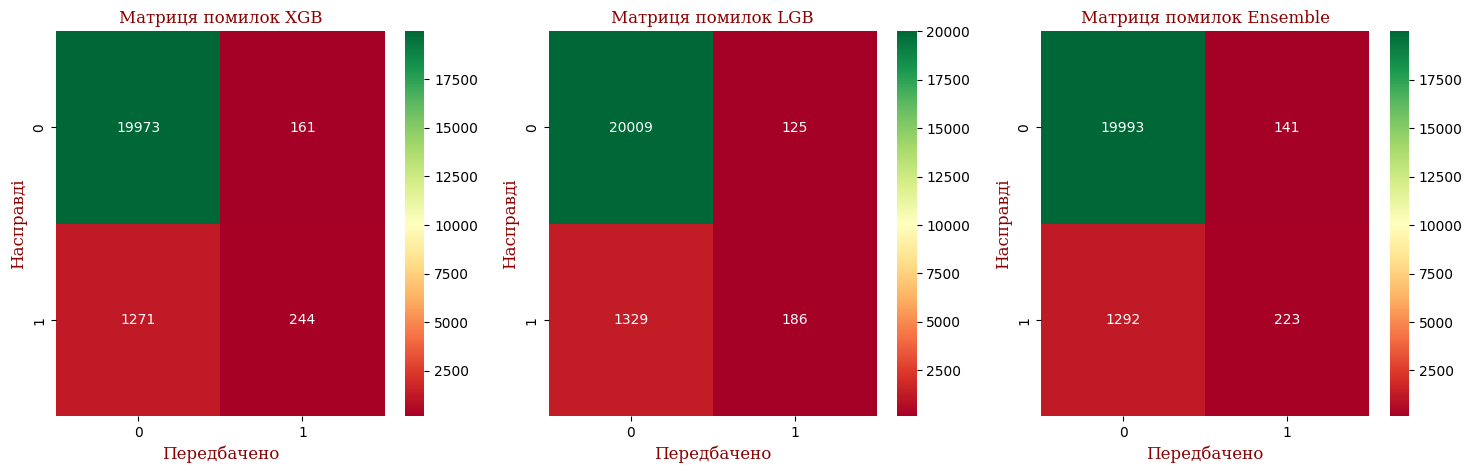

In [104]:
plt.figure(figsize=(18, 5))


plt.subplot(1, 3, 1)

y_pred_xgb = (y_proba_xgb_val > 0.5).astype(int)

cm = confusion_matrix(y_val, y_pred_xgb)
sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn')
plt.xlabel('Передбачено', fontdict=myfont)
plt.ylabel('Насправді', fontdict=myfont)
plt.title('Матриця помилок XGB', fontdict=myfont)


plt.subplot(1, 3, 2)

y_pred_lgb = (y_proba_lgb_val > 0.5).astype(int)

cm = confusion_matrix(y_val, y_pred_lgb)
sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn')
plt.xlabel('Передбачено', fontdict=myfont)
plt.ylabel('Насправді', fontdict=myfont)
plt.title('Матриця помилок LGB', fontdict=myfont)



plt.subplot(1, 3, 3)

y_pred_ens = (y_proba_ens_val > 0.5).astype(int)

cm = confusion_matrix(y_val, y_pred_ens)
sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn')
plt.xlabel('Передбачено', fontdict=myfont)
plt.ylabel('Насправді', fontdict=myfont)
plt.title('Матриця помилок Ensemble', fontdict=myfont)


plt.show()

True Positives - 19973 - модель вгадує 0 там, де він має бути.  
True Negatives - 244 - модель вгадує 1 там, де вона має бути.  
False Positives - 1271 - не вгадала де 1  
False Negatives - 161 - не вгадала де 0

True Positives - 20009 модель вгадує 0 там, де він має бути.  
True Negatives - 186 - модель вгадує 1 там, де вона має бути.  
False Positives - 1329 - не вгадала де 1.  
False Negatives - 125 - не вгадала де 0.  

True Positives - 19993 модель вгадує 0 там, де він має бути.  
True Negatives - 223 - модель вгадує 1 там, де вона має бути.  
False Positives - 1292 - не вгадала де 1.  
False Negatives - 141 - не вгадала де 0. 

In [68]:
y_1 = y_val.value_counts()[1]

In [69]:
res = (1271 / y_1) * 100
print(f'Модель загубила {res:.2f}% неплатників')

Модель загубила 83.89% неплатників


In [72]:
res = (1329 / y_1) * 100
print(f'Модель загубила {res:.2f}% неплатників')

Модель загубила 87.72% неплатників


In [81]:
res = (1292 / y_1) * 100
print(f'Модель загубила {res:.2f}% неплатників')

Модель загубила 85.28% неплатників


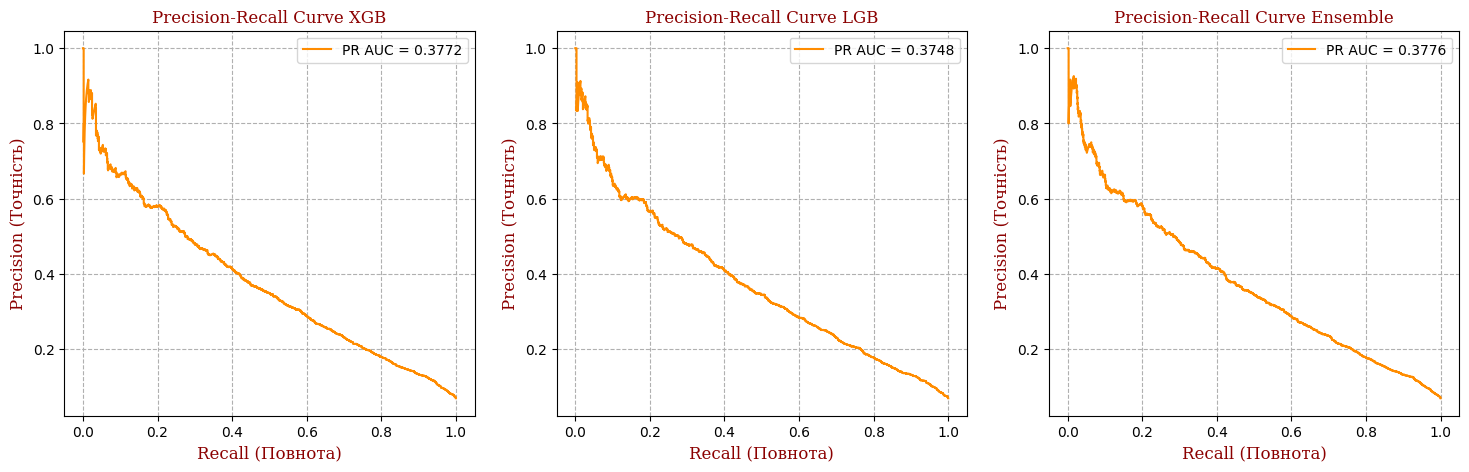

In [114]:
plt.figure(figsize=(18, 5))


plt.subplot(1, 3, 1)

precision, recall, thresholds = precision_recall_curve(y_val, y_proba_xgb_val)

pr_auc_xgb = calculate_auc(recall, precision)

plt.plot(recall, precision, color='darkorange', label=f'PR AUC = {pr_auc_xgb:.4f}')

plt.xlabel('Recall (Повнота)', fontdict=myfont)
plt.ylabel('Precision (Точність)', fontdict=myfont)
plt.title('Precision-Recall Curve XGB', fontdict=myfont)
plt.legend(loc="upper right")
plt.grid(True, linestyle='--')



plt.subplot(1, 3, 2)

precision, recall, thresholds = precision_recall_curve(y_val, y_proba_lgb_val)

pr_auc_lgb = calculate_auc(recall, precision)

plt.plot(recall, precision, color='darkorange', label=f'PR AUC = {pr_auc_lgb:.4f}')

plt.xlabel('Recall (Повнота)', fontdict=myfont)
plt.ylabel('Precision (Точність)', fontdict=myfont)
plt.title('Precision-Recall Curve LGB', fontdict=myfont)
plt.legend(loc="upper right")
plt.grid(True, linestyle='--')


plt.subplot(1, 3, 3)

precision, recall, thresholds = precision_recall_curve(y_val, y_proba_ens_val)

pr_auc_ens = calculate_auc(recall, precision)

plt.plot(recall, precision, color='darkorange', label=f'PR AUC = {pr_auc_ens:.4f}')

plt.xlabel('Recall (Повнота)', fontdict=myfont)
plt.ylabel('Precision (Точність)', fontdict=myfont)
plt.title('Precision-Recall Curve Ensemble', fontdict=myfont)
plt.legend(loc="upper right")
plt.grid(True, linestyle='--')


plt.show()

Змінюючи трешхолд у нашій матриці помилок ми звісно можемо покращити параметр False Positives,  
погіршивши при цьому інші параметри, залежить від вимог поставлених до задачі.  
Чи хочемо ми зайвий раз турбувати більше людей, які не мають дефолту для того, щоб отримати більше людей, які не платять.

In [87]:
thresholds = np.linspace(0, 1, 101)
f1_xgb = [f1_score(y_val, y_proba_xgb_val > t) for t in thresholds]
f1_lgb = [f1_score(y_val, y_proba_lgb_val > t) for t in thresholds]
f1_ens = [f1_score(y_val, y_proba_ens_val > t) for t in thresholds]

best_th_xgb = thresholds[np.argmax(f1_xgb)]
best_th_lgb = thresholds[np.argmax(f1_lgb)]
best_th_ens = thresholds[np.argmax(f1_ens)]

In [89]:
print(f'Оптимальні трешхолди для матриці помилок:'
      f'\nXGB: {best_th_xgb}'
      f'\nLGB: {best_th_lgb}'
      f'\nENS: {best_th_ens}')

Оптимальні трешхолди для матриці помилок:
XGB: 0.17
LGB: 0.16
ENS: 0.24


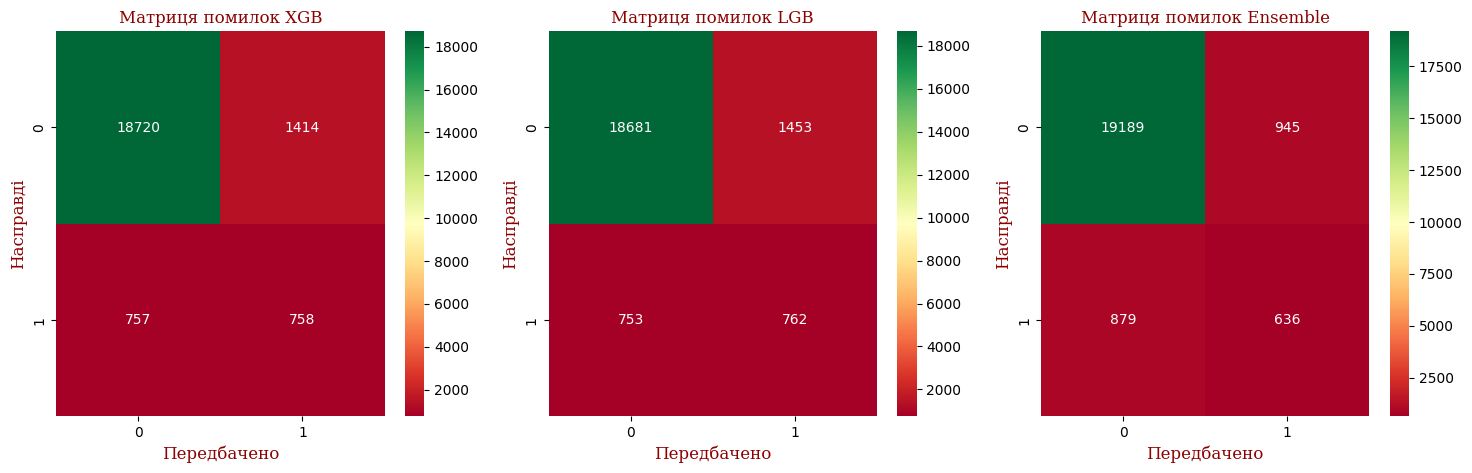

In [94]:
plt.figure(figsize=(18, 5))


plt.subplot(1, 3, 1)

y_pred_xgb = (y_proba_xgb_val > 0.17).astype(int)

cm = confusion_matrix(y_val, y_pred_xgb)
sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn')
plt.xlabel('Передбачено', fontdict=myfont)
plt.ylabel('Насправді', fontdict=myfont)
plt.title('Матриця помилок XGB', fontdict=myfont)


plt.subplot(1, 3, 2)

y_pred_lgb = (y_proba_lgb_val > 0.16).astype(int)

cm = confusion_matrix(y_val, y_pred_lgb)
sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn')
plt.xlabel('Передбачено', fontdict=myfont)
plt.ylabel('Насправді', fontdict=myfont)
plt.title('Матриця помилок LGB', fontdict=myfont)



plt.subplot(1, 3, 3)

y_pred_ens = (y_proba_ens_val > 0.24).astype(int)

cm = confusion_matrix(y_val, y_pred_ens)
sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn')
plt.xlabel('Передбачено', fontdict=myfont)
plt.ylabel('Насправді', fontdict=myfont)
plt.title('Матриця помилок Ensemble', fontdict=myfont)


plt.show()

In [97]:
print(classification_report(y_val, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.96      0.93      0.95     20134
           1       0.35      0.50      0.41      1515

    accuracy                           0.90     21649
   macro avg       0.66      0.72      0.68     21649
weighted avg       0.92      0.90      0.91     21649



In [98]:
print(classification_report(y_val, y_pred_lgb))

              precision    recall  f1-score   support

           0       0.96      0.93      0.94     20134
           1       0.34      0.50      0.41      1515

    accuracy                           0.90     21649
   macro avg       0.65      0.72      0.68     21649
weighted avg       0.92      0.90      0.91     21649



In [99]:
print(classification_report(y_val, y_pred_ens))

              precision    recall  f1-score   support

           0       0.96      0.95      0.95     20134
           1       0.40      0.42      0.41      1515

    accuracy                           0.92     21649
   macro avg       0.68      0.69      0.68     21649
weighted avg       0.92      0.92      0.92     21649



Усі наші моделі показують одну і ту саму проблему дисбалансу даних.  
Модель пізнає платників, але пропускає потенційні дефолти.  

Спробуємо використати Smote балансування.  
Подивимось, чи погіршимо ми результат перенавчанням.

In [109]:
auc = roc_auc_score(y_val, y_proba_smote)
loss = log_loss(y_val, y_proba_smote)

print(f'SMOTE'
      f'\nROC AUC: {auc:.4f}'
      f'\nLog-Loss: {loss:.4f}')

SMOTE
ROC AUC: 0.8276
Log-Loss: 0.2020


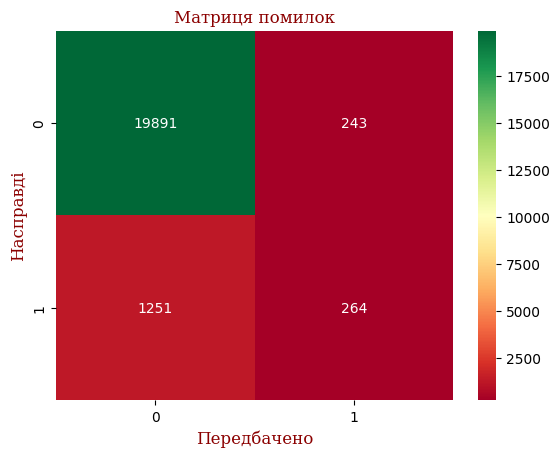

In [110]:
y_pred_smote = (y_proba_smote > 0.5).astype(int)

cm = confusion_matrix(y_val, y_pred_smote)
sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn')
plt.xlabel('Передбачено', fontdict=myfont)
plt.ylabel('Насправді', fontdict=myfont)
plt.title('Матриця помилок', fontdict=myfont)
plt.show()

In [111]:
res = (1251 / y_1) * 100
print(f'Модель загубила {res:.2f}% неплатників')

Модель загубила 82.57% неплатників


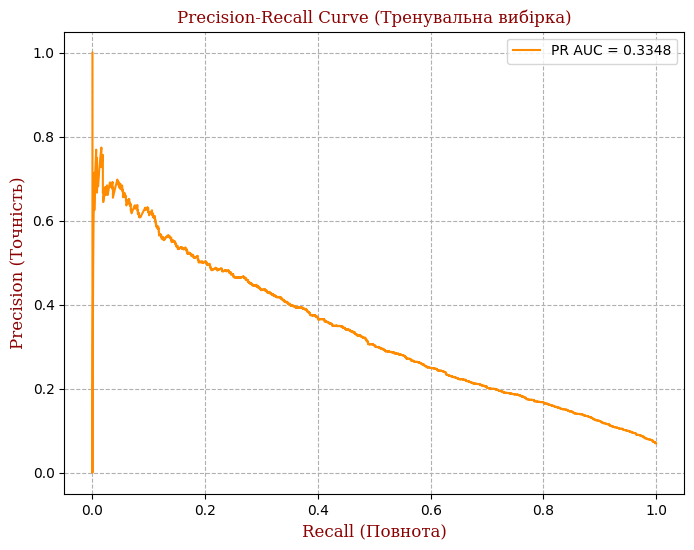

In [115]:
precision, recall, thresholds = precision_recall_curve(y_val, y_proba_smote)

pr_auc_sm = calculate_auc(recall, precision)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='darkorange', label=f'PR AUC = {pr_auc_sm:.4f}')

plt.xlabel('Recall (Повнота)', fontdict=myfont)
plt.ylabel('Precision (Точність)', fontdict=myfont)
plt.title('Precision-Recall Curve (Тренувальна вибірка)', fontdict=myfont)
plt.legend(loc="upper right")
plt.grid(True, linestyle='--')

plt.show()

Чітко бачимо, що метод SMOTE працює так само як і параметр scale_pos_weight який був зазначений у моделях.  
Також потрібно бути дуже уважними і не перенавчити модель підсунувши їй такі "збалансовані" дані.

### Подивимось на важливість наших ознак.

In [128]:
from xgboost import plot_importance
import shap

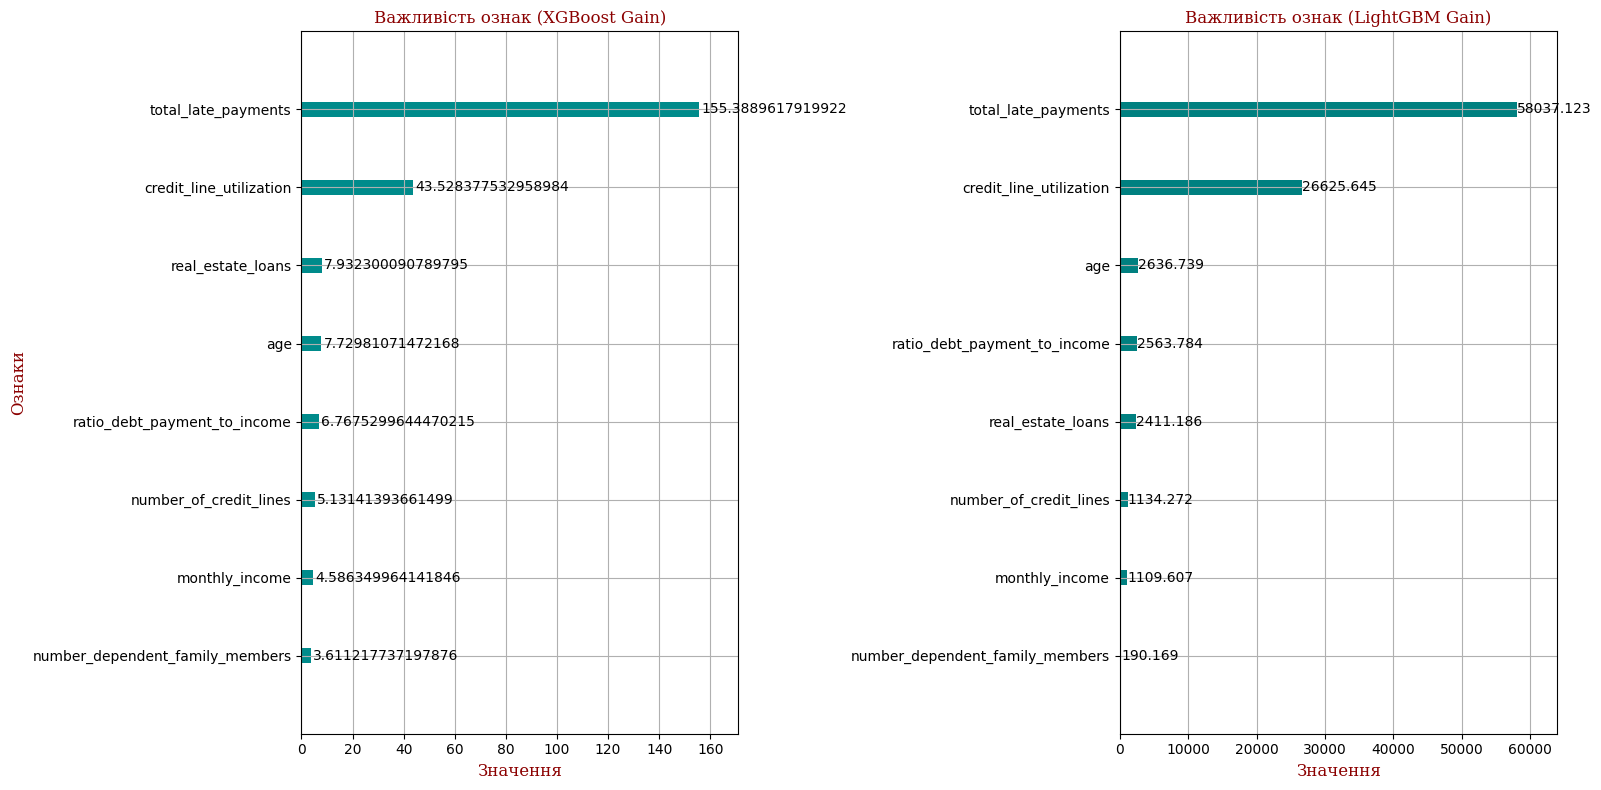

In [129]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

plot_importance(xgb_model, importance_type='gain', max_num_features=8, color='DarkCyan', ax=ax1)
ax1.set_title('Важливість ознак (XGBoost Gain)', fontdict=myfont)
ax1.set_xlabel('Значення', fontdict=myfont)
ax1.set_ylabel('Ознаки', fontdict=myfont)


lgb.plot_importance(lgb_model, importance_type='gain', max_num_features=8, color='Teal', ax=ax2)
ax2.set_title('Важливість ознак (LightGBM Gain)', fontdict=myfont)
ax2.set_xlabel('Значення', fontdict=myfont)
ax2.set_ylabel('')

plt.tight_layout()
plt.show()

Середній внесок ознак в обох моделях схожий.  
Найбільше моделі орієнтувались на тих хто мав затримку по виплатах - 'total late payment', що досить логічно.  
'credit_line_utilization' на другому місці оскільки показує як активно клієнт користується кредитними грошима.
Далі показники трохи розходяться.  
XGB вважає, що наявність іпотеки має бути на третьому місці так як впливає на розмір щомісячних виплат.  
Коли LGB більше звертає увагу на вік та відношення виплат до доходу.  
Бачимо, що ні ромір родини, ні дохід, ні кількість карток взагалі не впливають на своєчасну оплату заборгованості.  
Мабуть якщо клієнт не хоче платити, або забув, він цього і не зробить, навіть якщо буде мати можливість.  
Трохи вказує на глобальну безвідповідальність з боку клієнтів банку.

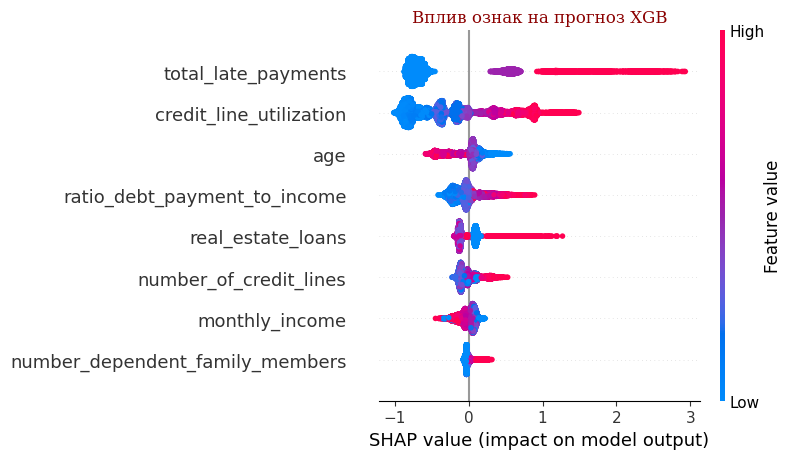

In [134]:
explainer_xgb = shap.TreeExplainer(xgb_model)
shap_values_xgb = explainer_xgb.shap_values(X_val)
plt.title('Вплив ознак на прогноз XGB', fontdict=myfont)
shap.summary_plot(shap_values_xgb, X_val)

C:\Python313\Lib\site-packages\shap\explainers\_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


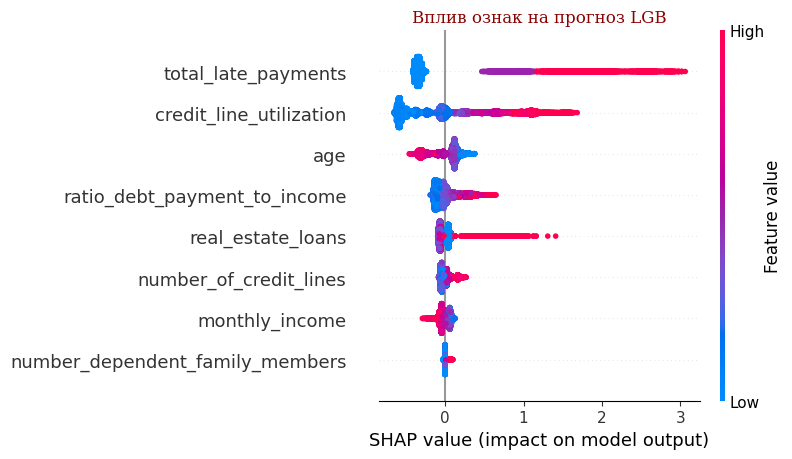

In [135]:
explainer_lgb = shap.TreeExplainer(lgb_model)
shap_values_lgb = explainer_lgb.shap_values(X_val)
plt.title('Вплив ознак на прогноз LGB', fontdict=myfont)
shap.summary_plot(shap_values_lgb, X_val)

SHAP графіки також вказують нам на те, що наступні ознаки, що тягнуться праворучь і мають червоний колір,  
найбільше натякали моделі де має бути дефолт : total_late_payments, credit_line_utilization, real_estate_loans, ratio_debt_payment_to_income.  

C:\Users\dell\AppData\Local\Temp\ipykernel_27544\3168096923.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


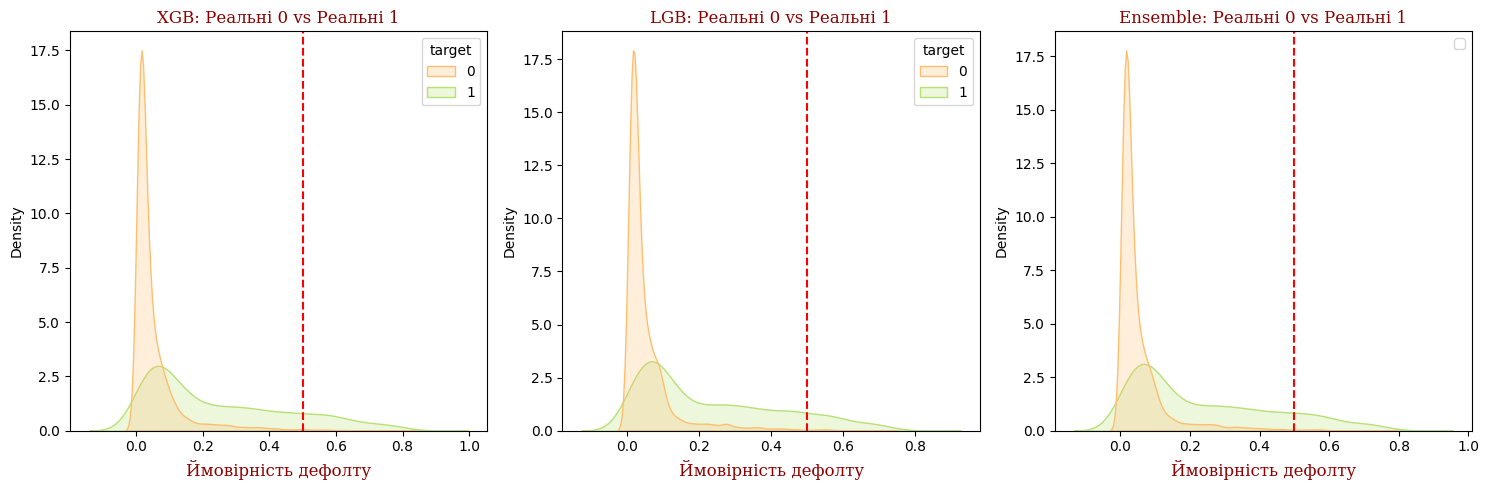

In [150]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.kdeplot(x=y_proba_xgb_val, hue=y_val, fill=True, common_norm=False, palette='RdYlGn')
plt.axvline(x=0.5, color='red', linestyle='--')
plt.title('XGB: Реальні 0 vs Реальні 1', fontdict=myfont)
plt.xlabel('Ймовірність дефолту', fontdict=myfont)


plt.subplot(1, 3, 2)
sns.kdeplot(x=y_proba_lgb_val, hue=y_val, fill=True, common_norm=False, palette='RdYlGn')
plt.axvline(x=0.5, color='red', linestyle='--')
plt.title('LGB: Реальні 0 vs Реальні 1', fontdict=myfont)
plt.xlabel('Ймовірність дефолту', fontdict=myfont)


plt.subplot(1, 3, 3)
sns.kdeplot(x=y_proba_ens_val, hue=y_val, fill=True, common_norm=False, palette='RdYlGn')
plt.axvline(x=0.5, color='red', linestyle='--')
plt.title('Ensemble: Реальні 0 vs Реальні 1', fontdict=myfont)
plt.xlabel('Ймовірність дефолту', fontdict=myfont)


plt.tight_layout()
plt.legend()
plt.show()

KDE графік показує нам, що дефолт і не дефолт наче накладаються один на одного.  
Тобто усі три моделі дають майже однакові значення вірогідності обом класам.

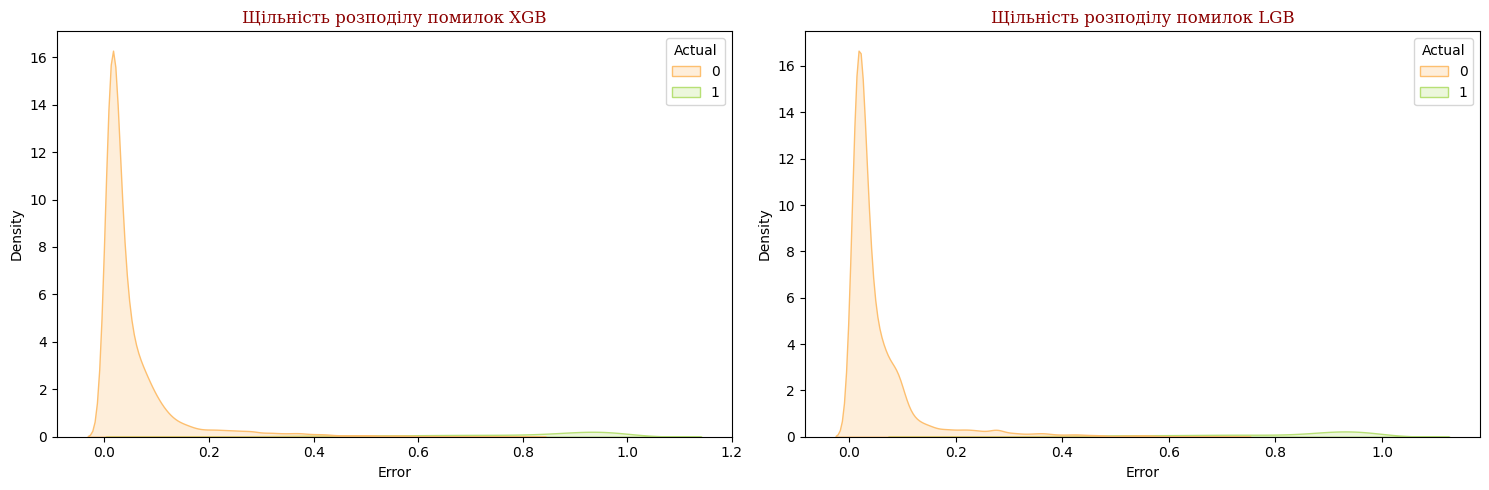

In [152]:
xgb_error = pd.DataFrame({
    'Actual': y_val,
    'Prob': y_proba_xgb_val,
    'Error': abs(y_val - y_proba_xgb_val)
})

lgb_error = pd.DataFrame({
    'Actual': y_val,
    'Prob': y_proba_lgb_val,
    'Error': abs(y_val - y_proba_lgb_val)
})


plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
sns.kdeplot(data=xgb_error, x='Error', hue='Actual', fill=True, palette='RdYlGn')
plt.title('Щільність розподілу помилок XGB', fontdict=myfont)

plt.subplot(1, 2, 2)
sns.kdeplot(data=lgb_error, x='Error', hue='Actual', fill=True, palette='RdYlGn')
plt.title('Щільність розподілу помилок LGB', fontdict=myfont)

plt.tight_layout()
plt.show()

Так само бачимо, що надійні клієнти класифікуються чітко і майже без помилок.  
Маємо великий помаранчевий пік в межах від 0 до 0.2.  
Зелена лінія, наш дефолт, ледь помітна, тягнеться до 1. Вона перегукується з надійними клієнтами, хоча має від них відрізнятись.

Треба подивитись де і чому модель не може відрізнити дефолт від надійних клієнтів.

XGBoost model

In [162]:
xgb_val_error = pd.concat([X_val.reset_index(drop=True), xgb_error.reset_index(drop=True)], axis=1)

fals_neg_xgb = xgb_val_error[xgb_val_error['Actual'] == 1].sort_values(by='Prob').head(5)

false_pos_xgb = xgb_val_error[xgb_val_error['Actual'] == 0].sort_values(by='Prob', ascending=False).head(5)

true_pos_xgb = xgb_val_error[xgb_val_error['Actual'] == 1].sort_values(by='Prob', ascending=False).head(5)

print('Пропущені дефолти False Negatives:')
display(fals_neg_xgb)

print('\nПомилкові дефолти False Positives:')
display(false_pos_xgb)

print('\nПравильні дефолти True Positive:')
display(true_pos_xgb)

Пропущені дефолти False Negatives:


,age,number_dependent_family_members,monthly_income,number_of_credit_lines,real_estate_loans,ratio_debt_payment_to_income,credit_line_utilization,total_late_payments,Actual,Prob,Error
15179,64,0,8.630700,6,1,0.244778,0.024081,0,1,0.005161,0.994839
12492,67,0,8.678632,7,1,0.333730,0.075352,0,1,0.006706,0.993294
12802,77,0,8.160804,9,1,0.148529,0.026134,0,1,0.006938,0.993062
3627,59,1,9.169623,8,0,0.045620,0.001885,0,1,0.007582,0.992418
20909,62,1,9.047939,19,2,0.191742,0.018149,0,1,0.007598,0.992402



Помилкові дефолти False Positives:


,age,number_dependent_family_members,monthly_income,number_of_credit_lines,real_estate_loans,ratio_debt_payment_to_income,credit_line_utilization,total_late_payments,Actual,Prob,Error
20526,59,0,8.594339,34,14,1.280078,0.176500,11,0,0.808440,0.808440
3873,38,0,8.343078,0,0,0.465365,1.043410,8,0,0.799764,0.799764
74,61,0,8.740497,22,2,1.364582,0.909348,8,0,0.764848,0.764848
18050,47,0,8.755580,9,7,1.187362,0.912358,4,0,0.760882,0.760882
17530,41,1,8.264363,5,0,0.174350,1.113736,6,0,0.735363,0.735363



Правильні дефолти True Positive:


,age,number_dependent_family_members,monthly_income,number_of_credit_lines,real_estate_loans,ratio_debt_payment_to_income,credit_line_utilization,total_late_payments,Actual,Prob,Error
17427,33,0,8.439664,18,1,0.948347,1.067231,9,1,0.851015,0.148985
6467,58,0,8.597297,12,9,1.500000,1.000000,7,1,0.839700,0.160300
11082,36,1,8.442901,12,6,1.500000,0.985570,10,1,0.839161,0.160839
2760,54,0,8.740497,17,2,1.055991,1.027639,5,1,0.802374,0.197626
12035,45,1,8.517393,14,4,1.500000,1.062215,4,1,0.793736,0.206264


LGBoost model

In [160]:
lgb_val_error = pd.concat([X_val.reset_index(drop=True), lgb_error.reset_index(drop=True)], axis=1)

fals_neg_lgb = lgb_val_error[lgb_val_error['Actual'] == 1].sort_values(by='Prob').head(5)

false_pos_lgb = lgb_val_error[lgb_val_error['Actual'] == 0].sort_values(by='Prob', ascending=False).head(5)

true_pos_lgb = lgb_val_error[lgb_val_error['Actual'] == 1].sort_values(by='Prob', ascending=False).head(5)

print("Пропущені дефолти False Negatives:")
display(fals_neg_lgb)

print("\nПомилкові дефолти False Positives:")
display(false_pos_lgb)

print("\nПравильні дефолти True Positive:")
display(true_pos_lgb)

Пропущені дефолти False Negatives:


,age,number_dependent_family_members,monthly_income,number_of_credit_lines,real_estate_loans,ratio_debt_payment_to_income,credit_line_utilization,total_late_payments,Actual,Prob,Error
15179,64,0,8.630700,6,1,0.244778,0.024081,0,1,0.007785,0.992215
18557,81,0,9.152711,0,0,0.000742,0.003829,0,1,0.008815,0.991185
7034,87,0,8.594339,7,0,0.010998,0.054184,0,1,0.009766,0.990234
12492,67,0,8.678632,7,1,0.333730,0.075352,0,1,0.009908,0.990092
12802,77,0,8.160804,9,1,0.148529,0.026134,0,1,0.010036,0.989964



Помилкові дефолти False Positives:


,age,number_dependent_family_members,monthly_income,number_of_credit_lines,real_estate_loans,ratio_debt_payment_to_income,credit_line_utilization,total_late_payments,Actual,Prob,Error
20526,59,0,8.594339,34,14,1.280078,0.176500,11,0,0.719620,0.719620
9460,46,2,8.006701,7,1,0.722426,1.184455,6,0,0.711536,0.711536
17940,45,2,7.824446,7,0,0.201919,1.500000,7,0,0.691229,0.691229
3873,38,0,8.343078,0,0,0.465365,1.043410,8,0,0.685898,0.685898
17530,41,1,8.264363,5,0,0.174350,1.113736,6,0,0.678820,0.678820



Правильні дефолти True Positive:


,age,number_dependent_family_members,monthly_income,number_of_credit_lines,real_estate_loans,ratio_debt_payment_to_income,credit_line_utilization,total_late_payments,Actual,Prob,Error
11082,36,1,8.442901,12,6,1.500000,0.985570,10,1,0.793554,0.206446
17427,33,0,8.439664,18,1,0.948347,1.067231,9,1,0.765982,0.234018
2760,54,0,8.740497,17,2,1.055991,1.027639,5,1,0.743063,0.256937
10639,56,0,8.434029,12,1,0.920887,1.017013,8,1,0.726768,0.273232
19703,41,2,9.226902,15,2,0.634897,1.002036,7,1,0.722736,0.277264


Це прекрасно. Вважала, що модель не впоралась із завданням, але це не так.  
Математично вона побудувала корректні, логічні взаємозв'язки.  
Та якість даних заплутує.  
Якщо візьмемо XGB модель, 'Пропущені дефолти False Negatives' - тут маємо високий дохід, займи по іпотеці 1-2 штуки, відношення боргових виплат до доходу низьке,  
утилізація кредитних коштів низька, і головне, нема запізнень по боргових виплатах. За всіма показниками - це надійні клієнти. Я б особисто їх так і класифікувала.  
Але чомусь наш таргет каже, що в них дефолт.  

Йдемо далі, 'Помилкові дефолти False Positives' - тут також маємо високий дохід, але, оскільки цей показник не відіграв для моделі основної ролі, він і не повпливав.  
Відношення боргових виплат до доходу - високе, утилізація кредитних коштів - висока, запізнення по боргових виплатах - купа. Однозначний дефолт.  
Але знов таргет дурить і каже, що це надійні клієнти.  

Нарешті чіткий результат, 'Правильні дефолти True Positive', іпотека, відношення боргових виплат до доходу - високе, утилізація кредитних коштів - висока, запізнення по боргових виплатах - теж маємо. Це точно дефолт. І от тут ми нарешті зійшлись думками з таргетом.  

З LGB така сама ситуація.

### Висновки

Ми отримали незбалансовані дані. Мали відношення 13.4 між надійними клієнтами і потенційним дефолтом.  

При попередній обробці датасету було застосовано ручний preprocessing. Значення NaN замінювалися, як на мою думку, необхідними величинами.  
Для боротьби з викидами великих ознак, як місячний дохід клієнта, застосувалось логарифмування.  
До параметрів, які мали б бути в межах від 0 до 1, застосовувалось обмеження по ліміту, адже все, що більше 1 все одно погано.  
Деякі викиди, наприклад по іпотеці, кількості кредитних ліній, та запізнень з виплатами, лишились без змін.  
Оскільки наші моделі мають витримати таке навантаження, а подібне втручання може спотворити реальні дані.  

Для того, щоб мати можливість дослідити наші моделі в реальних умовах, я забрала 30% від тренувального датасету.  
Щоб в якості валідаційних даних застосувати їх в поточному файлі.

Тесовий датасет був використаний виключно для submission результатів.  

І що ж ми отримали.  
Використані моделі XGBoost, LGBoost, та ансамбль з їх середнього значення, визначення оптимальних параметрів за допомогою Optuna.  
Усі розрахунки показали майже ідентичний результат.  
Оскільки маємо великий дисбаланс, багато надійних клієнтів - 0, і мало боржників - 1, нашим моделям достатньо було гарно визначати мажорний клас,  
тобто надійних клієнтів. І з цим усі моделі чудово впорались.  
А що ж робити з боржниками, найголовнішим фінансовим завданням, не надавати кредити тим, хто не повертає займ.  
І ось тут моделі дали поганий результат, більше 80% боржників лишились непоміченими.  
Щоб дати моделям зрозуміти, що треба працювати з дисбалансом і звертати більше уваги на мінорний клас, було додано спеціальний параметр 'scale_pos_weight'  
який чітко вказував вирахуване співвідношення 13.4.  
Моделі все одно не захотіли шукати боржників.  

Задля порівняльного експерименту, для окремої моделі, теж XGBoost, було застосовано метод балансування SMOTE, який мав би нам допомогти.  
Нажаль, він може створити більше проблем, ніж дати рішення.  
Синтетично створенні данні можуть потягти з собою перенавчання моделі. Ми можемо отримати гарну оцінку точності, але повністю провалитись потім на тестовій вибірці.  
При обережному використанні ми уникли overfitting, і отримали такий самий результат як і без SMOTE.  

Після більш детального дослідження важливості ознак та розподілу помилок, стало видно, що моделі, з якихось причин, не розрізняють надійних клієнтів і боржників.  
Графіки постійно пересікались.  

І от поглянувши в кінці саме на зразки клієнтів, стало більш зрозуміло, з чим працювали моделі.  
За певними ознаками, які однозначно вказують на боржника, такі як висока утилізація рахунків, і невиплати по займам, наданий таргет плутає і каже, що це надійний клієнт.  
І навпаки, там де відповідальна людина, не пропускає виплати і не лізе в борги, таргет каже, що це боржник.  
Тільки у дуже маленькій вибірці клієнтів, можна побачити реальну логічну залежність між ознаками і таргетом.  

Для вирішення проблеми була спроба застосувати SMOTE, але він не покращив результати. Іноді його використання може бути навіть ризикованим.  
Можна було б застосувати кластеризацію, і самостіно створити таргет. Але, якщо зробити припущення, що дані були отримані з банку безпосередньо,  
і саме так клієнти класифікуються в межах установи, зміна таргету спотворить вхідні дані.

Існують наче методи по принципу Anomaly Detection, які можуть допомогти знайти таких клієнтів,  
в кого таргет суперечить поведімці. Але видаляти такі випадки це, на мою думку, може погіршити дисбаланс,  
і знову ж таки спотворити дані. Будь яка зміна в цих даних теж їх спотворює.  

Можливо кращих результатів можна досягти з більш чистими даними.  
Загалом, вважаю, що моделі чудово вхопили зв'язок між ознаками і надали логічні передбачення.
